# Inference of the relation between $r_h$ and $\sigma_v$

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
from glob import glob
import os

%matplotlib inline

In [162]:
res_path = '../result/10D/'
fig_path = '../figure/'



In [163]:
files = glob(os.path.join(res_path, "Dwarf*"))
files.sort()
print (len(files))

20


In [164]:
n_samples = 100
rh_dg = np.zeros((20, n_samples))
dvr_dg = np.zeros((20, n_samples))



for i in range(20):

    samples = np.loadtxt(files[i])

    indices = np.random.choice(len(samples), n_samples, replace=False)
    # print(indices.shape)
    draw_samples = samples[indices]

    rh_dg[i,:] = np.sqrt(draw_samples[:,2]**2.+draw_samples[:,3]**2.)*1.1774
    dvr_dg[i,:] = draw_samples[:,6]

    

In [165]:
def dvr_model(a, b, rh):
    dvr = a * rh + b
    return dvr


# for each pair of (a, b), calculate the loglikelihood assuming the unceratinty of relation is sigma 
def log_Likelihood(theta, rh, dvr):

    a, b, sigma = theta
    
    L = 1/np.sqrt(2*np.pi)/sigma * np.exp(-0.5*(dvr_model(a, b, rh) - dvr)**2./ sigma**2.)
    logL = np.sum(np.log(L))

    return logL

In [166]:
rh_mod = np.linspace(0, 1200, 1000)

a0 = 0.02
b0 = 0
dvr_mod = dvr_model(a0, b0, rh_mod)

(0.0, 25.0)

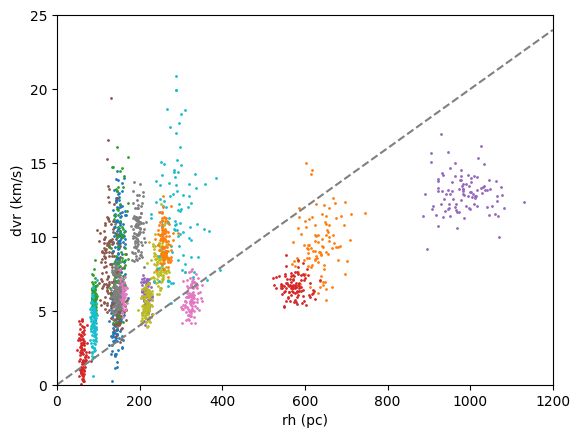

In [167]:
plt.figure()

for i in range(20):

    # if i == 19:
    plt.scatter(rh_dg[i, :], dvr_dg[i, :], s=1)

plt.plot(rh_mod, dvr_mod, color='.5', label='model', ls="dashed")
plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)





In [192]:
print (rh_dg.shape)
print (dvr_dg.shape)
print (rh_dg[:,0])

(20, 100)
(20, 100)
[140.80157105 649.94328109  86.57045203 559.60169333 227.48372652
 143.41275464 321.26817513 197.35121816 268.81030535 285.89501483
 168.2661202  269.57364667 141.7816838   62.55145725 905.10942427
 113.2393839  156.05453137 139.93979214 206.44451523  85.31162227]


In [224]:
samples_tot = []
nsteps = 50000
for j in range(n_samples):


    a0 = 0.02
    b0 = 2.
    sigma0 = 1.

    param0 = a0, b0, sigma0

    logL0 = log_Likelihood(param0, rh_dg[:,j], dvr_dg[:,j])

    # refine the following steps based on the uncertainties of the results
    step_a = 1e-2
    step_b = 5e-1
    step_sigma = 5e-1
    accept = 1

    samples = np.zeros((nsteps, 5))

    for i in range(nsteps):

        param1 = param0
        logL1 = logL0

        samples[i, :3] = param1
        samples[i, 3] = logL1
        samples[i, 4] = accept

        accept = 0

        a1, b1, sigma1 = param1
        a1 = a1 + np.random.normal(0, step_a)   
        b1 = b1 + np.random.normal(0, step_b)
        sigma1 = sigma1 + np.random.normal(0, step_sigma)
   
        param1 = a1, b1, sigma1

        # assuming the axis changing from 0 to pi/2, may need to adjust to (-pi/4 to pi/4) for some dwarfs

        if (0 <sigma1) :
    
            logL1 = log_Likelihood(param1, rh_dg[:,j], dvr_dg[:,j])      

            if logL1 > logL0:

                param0 = param1
                logL0 = logL1
                accept = 1

            else:

                a = np.random.uniform(0, 1)
                if (logL1-logL0) > np.log(a):

                    param0 = param1
                    logL0 = logL1
                    accept = 1

    samples_tot.append(samples)


/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_7291/3610834563.py:12: RuntimeWarning: divide by zero encountered in log
  logL = np.sum(np.log(L))


In [233]:
print (samples_tot[99].shape)
samples_check = samples_tot[0]


(50000, 5)


In [221]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples_check[:, -1] == 1
print ("acceptance rate", len(samples_check[ind_accept, -1])/nsteps)
samples_cut =  samples_check[int(nsteps*0.2):]

acceptance rate 0.2052


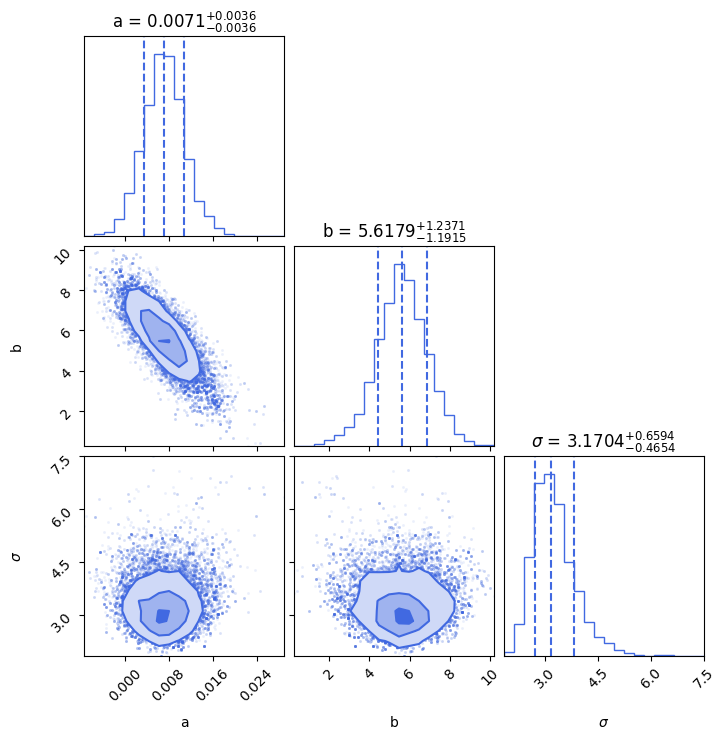

In [223]:
fig = corner.corner(
    samples_cut[:,:3],
    labels=[r"a", r"b", r"$\sigma$"],
    show_titles=True,
    title_fmt=".4f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True)


# plt.savefig(fig_path+'linear_relation_rh_sigma_%i_samplings.png'%n_samples, dpi=300)

In [234]:
samples_chain = samples_tot[0][int(nsteps*0.2):]
for i in range(99):

    samples_cut =  samples_tot[i+1][int(nsteps*0.2):]

    samples_chain= np.concatenate((samples_chain, samples_cut), axis=0)

print (samples_chain.shape)



(4000000, 5)


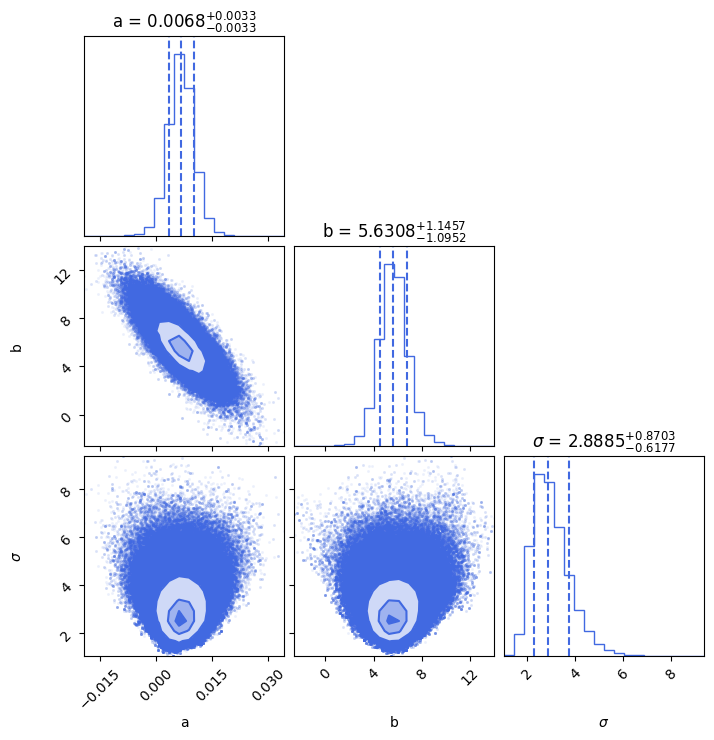

In [235]:
fig = corner.corner(
    samples_chain[:,:3],
    labels=[r"a", r"b", r"$\sigma$"],
    show_titles=True,
    title_fmt=".4f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True)


# plt.savefig(fig_path+'linear_relation_rh_sigma_%i_samplings.png'%n_samples, dpi=300)

In [237]:
samples_chain.shape

(4000000, 5)

In [238]:
ind_best = np.argmax(samples_chain[:, 3])
print (samples_chain[ind_best, :3])

[4.30253605e-03 5.73349326e+00 1.68071678e+00]


(0.0, 25.0)

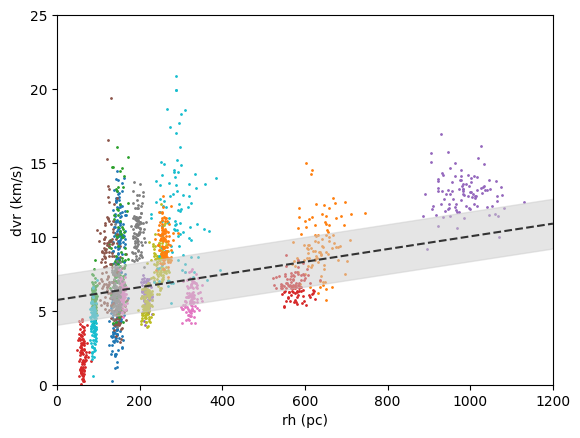

In [239]:
rh_mod = np.linspace(0, 1200, 1000)

dvr_mod = dvr_model(samples_chain[ind_best, 0], samples_chain[ind_best, 1], rh_mod)

plt.figure()

for i in range(20):

    # if i == 19:
    plt.scatter(rh_dg[i, :], dvr_dg[i, :], s=1)

plt.plot(rh_mod, dvr_mod, color='.2', label='model', ls="dashed")
plt.fill_between(rh_mod, dvr_mod-samples_chain[ind_best, 2], dvr_mod+samples_chain[ind_best, 2], color='.8', alpha=0.5, label='1 sigma')

plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)

In [240]:
indices = np.random.choice(len(samples_chain), 20, replace=False)
print(indices.shape)
samples1 = samples_chain[indices]


(20,)


(0.0, 25.0)

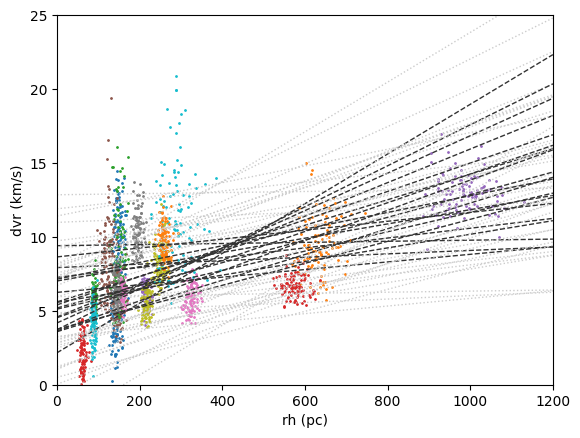

In [241]:
rh_mod = np.linspace(0, 1200, 1000)

plt.figure()

for i in range(20):

    # if i == 19:
    plt.scatter(rh_dg[i, :], dvr_dg[i, :], s=1)


for i in range(len(samples1)):
    dvr_mod = dvr_model(samples1[i, 0], samples1[i, 1], rh_mod)

    plt.plot(rh_mod, dvr_mod, color='.2', lw=1, label='model', ls="dashed")
    plt.plot(rh_mod, dvr_mod-samples1[i, 2], lw=1, ls="dotted", color='.8')
    plt.plot(rh_mod, dvr_mod+samples1[i, 2], lw=1, ls="dotted", color='.8')

plt.xlabel("rh (pc)")
plt.ylabel("dvr (km/s)")
plt.xlim(0, 1200)
plt.ylim(0, 25)